# 02 data preprocessing and feature engineering

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## load dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel(DATA_DIR / "carbon_footprint_dataset.xlsx")


## data cleaning

In [3]:
# df = df.dropna()  # drop rows with any null
# df["household_size"] = df["household_size"].replace(0, 1)   # avoid divide-by-zero
# print("rows after cleaning:", len(df))

## feature engineering

In [4]:
# per-capita
df["energy_per_person"] = df["electricity_kwh_per_month"] / df["household_size"]
df["food_per_person"]   = df["food_spend_usd_per_month"] / df["household_size"]
df["waste_per_person"]  = df["waste_kg_per_month"] / df["household_size"]
df["gas_per_person"]  = df["natural_gas_therms_per_month"] / df["household_size"]
df["fuel_per_person"] = df["fuel_liters_per_month"] / df["household_size"]
df["car_per_person"]  = df["car_km_per_month"] / df["household_size"]
df["meat_per_person"] = df["meat_kg_per_month"] / df["household_size"]

df["transport_ratio"] = df["car_km_per_month"] / (df["public_transport_km_per_month"] + 1)  # +1 avoids division by zero
df["high_meat_consumption"] = (df["meat_kg_per_month"] > df["meat_kg_per_month"].median()).astype(int)
df["log_income"] = np.log1p(df["annual_income_usd"])  # log compresses right-skewed income

df.head()

,household_size,annual_income_usd,electricity_kwh_per_month,natural_gas_therms_per_month,fuel_liters_per_month,food_spend_usd_per_month,meat_kg_per_month,waste_kg_per_month,public_transport_km_per_month,car_km_per_month,...,energy_per_person,food_per_person,waste_per_person,gas_per_person,fuel_per_person,car_per_person,meat_per_person,transport_ratio,high_meat_consumption,log_income
0,4,29397,1143.4,35.6,145.2,1147.93,7.06,57.1,42.1,368.9,...,285.850000,286.982500,14.275000,8.900000,36.300000,92.225,1.765,8.559165,0,10.288682
1,5,146800,542.0,145.7,163.6,1047.98,17.88,21.4,237.2,404.6,...,108.400000,209.596000,4.280000,29.140000,32.720000,80.920,3.576,1.698573,1,11.896833
2,3,134180,434.3,27.1,42.7,1299.29,18.93,49.6,109.1,773.4,...,144.766667,433.096667,16.533333,9.033333,14.233333,257.800,6.310,7.024523,1,11.806945
3,5,81234,826.2,128.2,101.2,1100.24,17.85,24.8,94.1,102.3,...,165.240000,220.048000,4.960000,25.640000,20.240000,20.460,3.570,1.075710,1,11.305101
4,5,54954,579.2,73.8,168.1,758.91,8.39,54.6,496.4,795.6,...,115.840000,151.782000,10.920000,14.760000,33.620000,159.120,1.678,1.599517,0,10.914270


## outlier inspection (IQR)

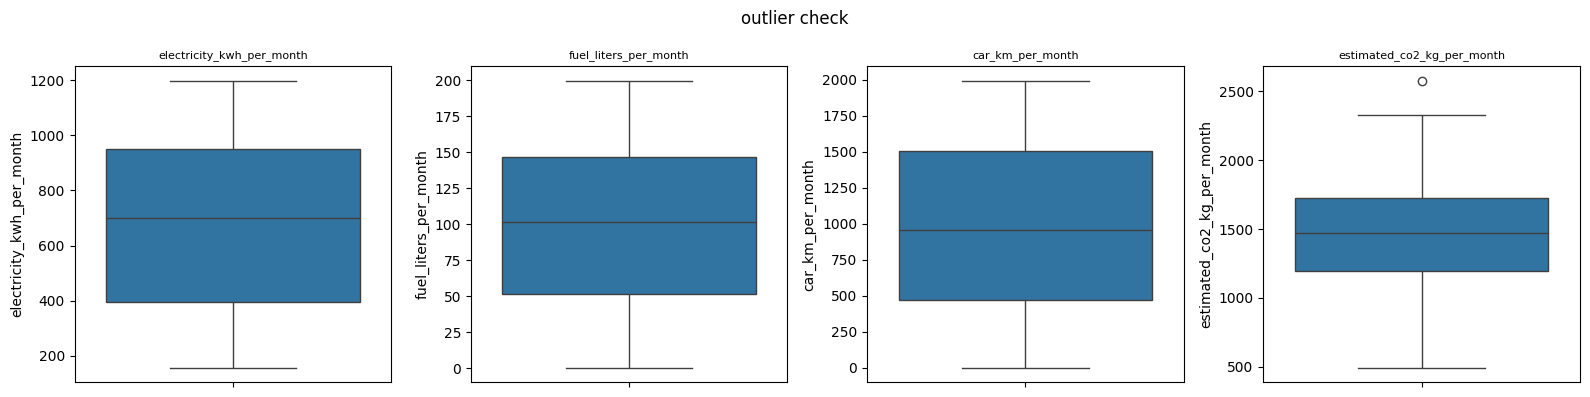

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

check_cols = ["electricity_kwh_per_month", "fuel_liters_per_month",  # focus on high-variance numeric columns
              "car_km_per_month", "estimated_co2_kg_per_month"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, check_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col, fontsize=8)

plt.suptitle("outlier check")
plt.tight_layout()
plt.show()

A few outliers flagged but kept — they look like genuine high-consumption households, not errors.

## target construction

Tertile split gives three roughly equal-sized classes.

In [6]:
# balanced 3-class label via quantile cut
df["carbon_level"] = pd.qcut(  # quantile cut → balanced 3-class label
    df["estimated_co2_kg_per_month"],
    q=3,  # tertile split: low / medium / high
    labels=["low", "medium", "high"]
)
print(df["carbon_level"].value_counts())

carbon_level
low       167
high      167
medium    166
Name: count, dtype: int64


## feature summary after engineering

In [7]:
engineered = ["energy_per_person", "food_per_person", "waste_per_person",
              "gas_per_person", "fuel_per_person", "car_per_person", "meat_per_person",
              "transport_ratio", "high_meat_consumption", "log_income", "carbon_level"]
df[engineered].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
energy_per_person,500.0,312.270,256.728,32.440,142.675,223.052,387.742,1197.000
food_per_person,500.0,392.485,322.099,42.038,181.794,287.224,481.629,1492.000
waste_per_person,500.0,19.518,17.278,1.000,8.122,14.083,24.162,79.900
gas_per_person,500.0,35.037,32.689,0.275,11.190,25.358,46.167,149.500
fuel_per_person,500.0,46.199,42.962,0.150,17.730,32.967,59.525,199.700
car_per_person,500.0,465.308,454.716,0.125,154.000,317.730,583.675,1988.700
meat_per_person,500.0,4.543,4.104,0.000,1.675,3.475,5.852,19.610
transport_ratio,500.0,12.938,72.704,0.001,1.563,3.350,6.711,1434.900
high_meat_consumption,500.0,0.500,0.501,0.000,0.000,0.500,1.000,1.000
log_income,500.0,11.153,0.610,9.624,10.713,11.300,11.677,11.918


## export processed dataset

In [8]:
df.to_csv(DATA_DIR / "processed_carbon_dataset.csv", index=False)  # downstream notebooks read this CSV
print("exported:", df.shape)


exported: (500, 22)
